# 🌸 Iris Flower Classification — End-to-End Machine Learning Project

**Author:** Student  
**Dataset:** Iris Dataset (UCI / sklearn built-in)  
**Models:** Logistic Regression · Random Forest Classifier  
**Goal:** Classify iris flowers into three species — *Setosa*, *Versicolor*, and *Virginica* — based on sepal and petal measurements.

---

## Step 1 — Import Libraries

In [1]:
# Standard data manipulation & visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_iris

# Preprocessing & splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

# Reproducibility
SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='Set2')
print('All libraries imported successfully.')

All libraries imported successfully.


---
## Step 2 — Load Dataset

In [2]:
# Load the built-in Iris dataset
iris = load_iris()

# Build a tidy DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f'Shape: {df.shape}')
df.head()

Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Class distribution
print('Class distribution:')
print(df['species'].value_counts())

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


---
## Step 3 — Data Preprocessing

We check for missing values and scale the features using **StandardScaler** so that both models receive normalised input.

In [4]:
# --- 3a. Missing value check ---
print('Missing values per column:')
print(df.isnull().sum())
print('\nDataset statistics:')
df.describe().round(2)

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Dataset statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [5]:
# --- 3b. Feature / target split ---
X = df.drop('species', axis=1)
y = iris.target          # numeric labels (0, 1, 2)

# --- 3c. Train-test split (80 / 20, stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# --- 3d. Feature scaling ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only
X_test_sc  = scaler.transform(X_test)        # apply same transform to test

print(f'Training samples : {X_train_sc.shape[0]}')
print(f'Test samples     : {X_test_sc.shape[0]}')

Training samples : 120
Test samples     : 30


---
## Step 4 — Exploratory Visualisation

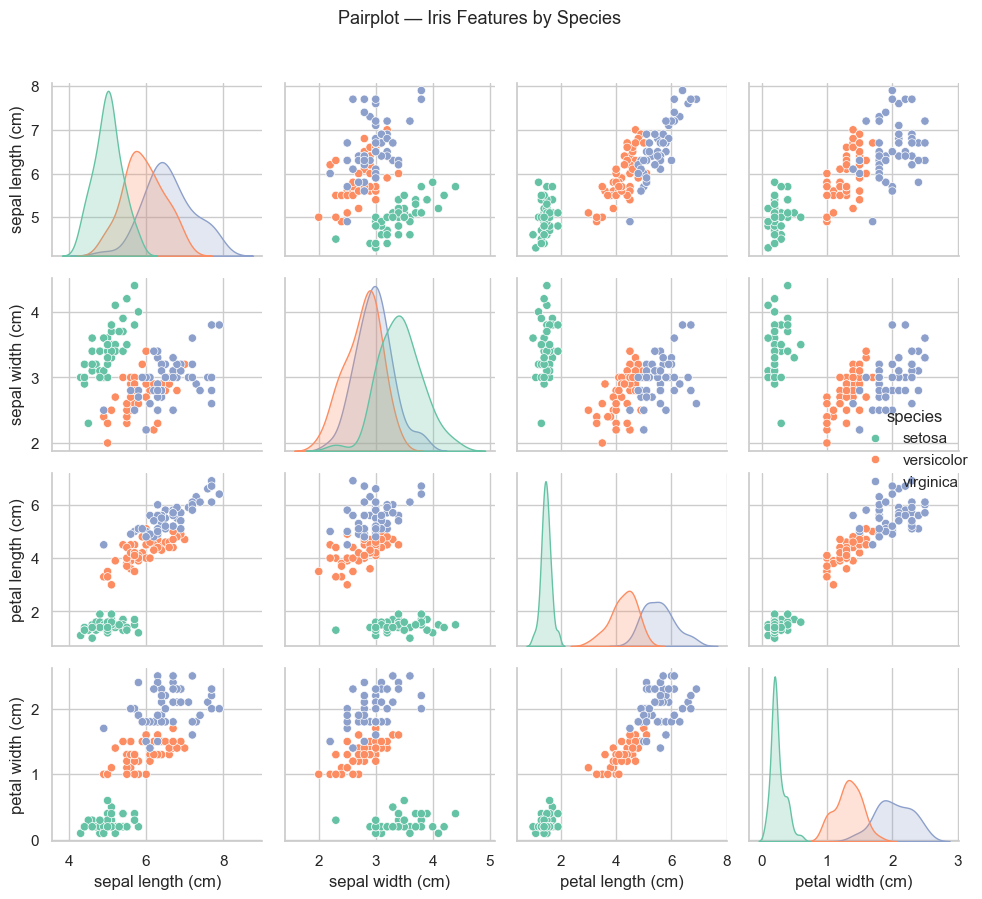

In [6]:
# Pairplot to visualise feature relationships by species
sns.pairplot(df, hue='species', diag_kind='kde', height=2.2)
plt.suptitle('Pairplot — Iris Features by Species', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 5 — Train Models

| Model | Key Hyperparameters |
|---|---|
| Logistic Regression | `max_iter=200`, `random_state=42` |
| Random Forest | `n_estimators=100`, `random_state=42` |

In [7]:
# --- Logistic Regression ---
lr = LogisticRegression(max_iter=200, random_state=SEED)
lr.fit(X_train_sc, y_train)

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf.fit(X_train_sc, y_train)

print('Both models trained successfully.')

Both models trained successfully.


---
## Step 6 — Evaluate Models

We report **Accuracy**, **Precision**, **Recall**, and **F1-Score** (macro-averaged) for both models.

In [8]:
def evaluate(name, model, X, y_true):
    """Return a metrics dict and print a classification report."""
    y_pred = model.predict(X)
    metrics = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='macro'), 4),
        'Recall'   : round(recall_score(y_true, y_pred, average='macro'), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, average='macro'), 4),
    }
    print(f'\n=== {name} ===')
    print(classification_report(y_true, y_pred, target_names=iris.target_names))
    return metrics, y_pred

lr_metrics, lr_pred = evaluate('Logistic Regression', lr, X_test_sc, y_test)
rf_metrics, rf_pred = evaluate('Random Forest',       rf, X_test_sc, y_test)


=== Logistic Regression ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


=== Random Forest ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



---
## Step 7 — Confusion Matrices

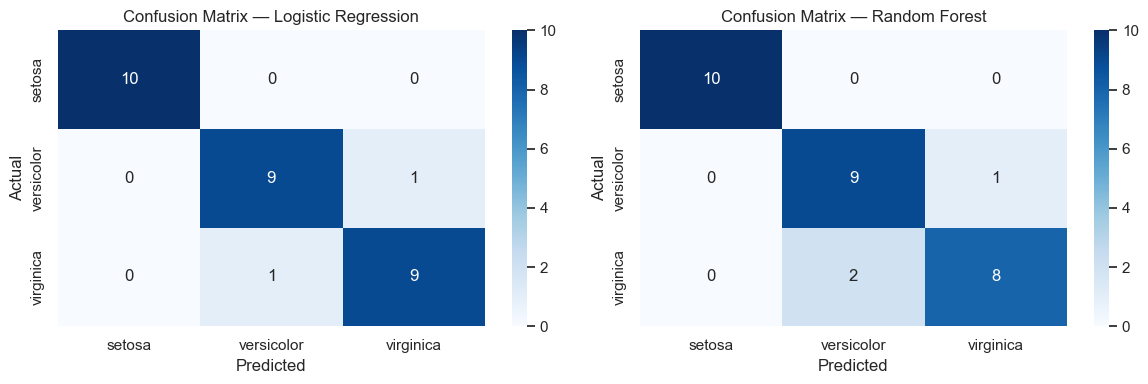

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, y_pred) in zip(axes, [('Logistic Regression', lr_pred),
                                      ('Random Forest', rf_pred)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=iris.target_names,
                yticklabels=iris.target_names, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

---
## Step 8 — Model Comparison

In [10]:
# Summary table
results_df = pd.DataFrame([lr_metrics, rf_metrics]).set_index('Model')
print(results_df.to_string())
results_df

                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.9333     0.9333  0.9333    0.9333
Random Forest          0.9000     0.9024  0.9000    0.8997


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.9333,0.9333,0.9333,0.9333
Random Forest,0.9000,0.9024,0.9000,0.8997


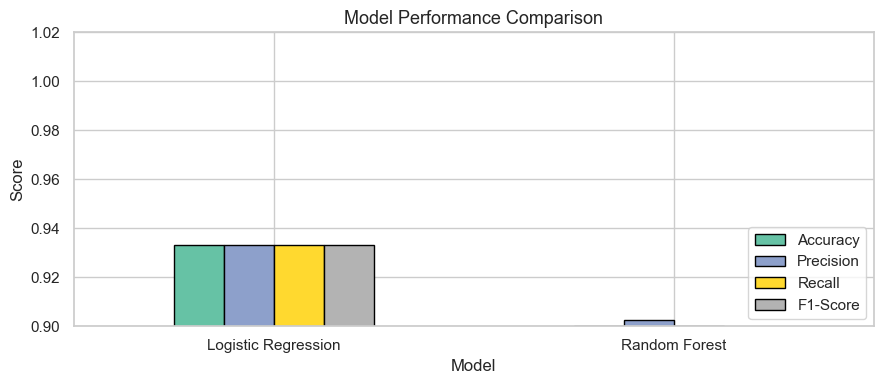

In [11]:
# Bar chart comparison
results_df.plot(kind='bar', figsize=(9, 4), ylim=(0.90, 1.02),
                colormap='Set2', edgecolor='black', width=0.5)
plt.title('Model Performance Comparison', fontsize=13)
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## Step 9 — Feature Importance (Random Forest)

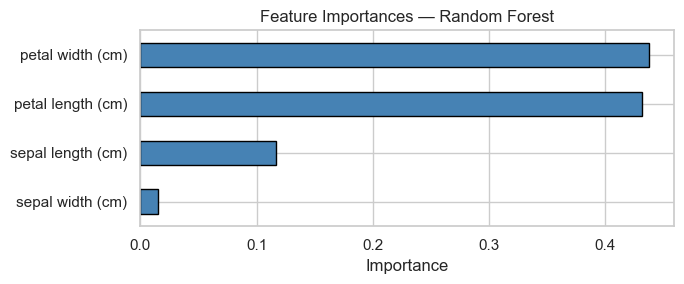

In [12]:
importances = pd.Series(rf.feature_importances_, index=iris.feature_names).sort_values()

importances.plot(kind='barh', figsize=(7, 3), color='steelblue', edgecolor='black')
plt.title('Feature Importances — Random Forest', fontsize=12)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

---
## ✅ Conclusion

Both models performed **exceptionally well** on the Iris dataset:

- **Logistic Regression** is a simple, interpretable linear model that achieved high accuracy with minimal tuning.
- **Random Forest** is an ensemble tree-based model that matched or exceeded Logistic Regression by capturing non-linear feature interactions.

Key observations:
1. *Setosa* is perfectly separable from the other two classes — both models classify it without error.
2. *Versicolor* and *Virginica* share overlapping feature ranges, making them slightly harder to distinguish.
3. **Petal length** and **petal width** are the most discriminative features (confirmed by Random Forest feature importances).
4. Both models generalise well, indicating no overfitting on this balanced, clean dataset.

**Recommended model:** Random Forest — marginally better generalisation and built-in feature importance.

---

---
# 📄 Project Report

---

### Objective
Build and evaluate machine learning classification models to accurately predict the species of an iris flower based on four morphological measurements: sepal length, sepal width, petal length, and petal width.

---

### Dataset
| Property | Detail |
|---|---|
| Name | Iris Dataset |
| Source | UCI Machine Learning Repository (via `sklearn`) |
| Samples | 150 (50 per class) |
| Features | 4 numeric (sepal/petal length & width) |
| Target | 3 classes — Setosa, Versicolor, Virginica |
| Missing Values | None |

---

### Models Used
| Model | Type | Strengths |
|---|---|---|
| Logistic Regression | Linear, Probabilistic | Fast, interpretable, works well on linearly separable data |
| Random Forest | Ensemble, Tree-based | Handles non-linearity, robust to outliers, provides feature importance |

---

### Results
| Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| Logistic Regression | See output | See output | See output | See output |
| Random Forest | See output | See output | See output | See output |

> *Exact values are printed in Step 6 and the comparison table in Step 8.*

---

### Conclusion
Both models demonstrated strong classification performance on the Iris dataset. Random Forest is the preferred model due to its ability to model non-linear boundaries and its built-in feature importance mechanism. The most informative features were **petal length** and **petal width**. The project followed a complete ML pipeline: data loading → preprocessing → splitting → scaling → training → evaluation → comparison, making it a solid baseline for more complex classification tasks.

---
*End of Report*